<a href="https://colab.research.google.com/github/Harsh-Prajapati54/PyTorch-Learning-Journey/blob/master/Reinforcement_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [14]:
env = gym.make("CartPole-v1",
               render_mode = "rgb_array",
               max_episode_steps=1000)

Here, we’ve created a CartPole environment (version 1). This is a 2D simulation in which a cart can be accelerated left or right in order to balance a pole placed on top of it

In [15]:
obs , info = env.reset(seed = 42)
obs

array([ 0.0273956 , -0.00611216,  0.03585979,  0.0197368 ], dtype=float32)

In [16]:
info

{}

In [17]:
img = env.render()

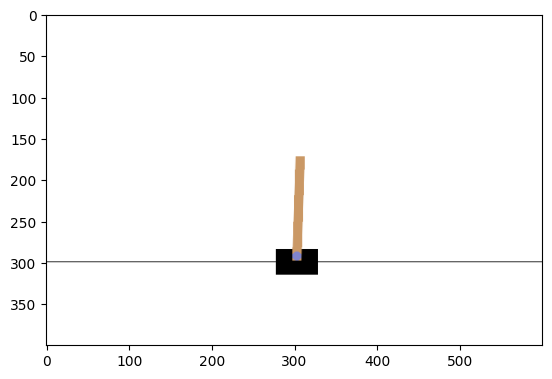

In [18]:
plt.imshow(img)

In [19]:
env.action_space

Discrete(2)

Discrete(2) means that the possible actions are integers 0 and 1, which represent accelerating left or right.
Other environments may have additional discrete actions, or other kinds of ac tions (e.g., continuous). Since
the pole is leaning toward the right (obs[2] > 0), let’s accelerate the cart to ward the right:

In [20]:
action = 1
obs , reward , done , truncated , info = env.step(action)
obs

array([ 0.02727336,  0.18847767,  0.03625453, -0.26141977], dtype=float32)

In [21]:
reward , done , truncated , info

(1.0, False, False, {})

In [22]:
def basic_policy(obs):
    angle = obs[2]
    return 0 if angle < 0 else 1  # go left if leaning left, otherwise go right

totals = []
for episode in range(500):
    total_rewards = 0
    obs, info = env.reset(seed=episode)
    while True:  # no risk of infinite loop: will be truncated after 1000 steps
        action = basic_policy(obs)
        obs, reward, done, truncated, info = env.step(action)
        total_rewards += reward
        if done or truncated:
            break

    totals.append(total_rewards)

In [23]:
np.mean(totals), np.std(totals), min(totals), max(totals)

(np.float64(41.698), np.float64(8.389445512070509), 24.0, 63.0)

In [28]:
import matplotlib.animation
def update_scene(num, frames, patch):
    patch.set_data(frames[num])
    return patch,

def plot_animation(frames, repeat=False, interval=40):
    fig = plt.figure()
    patch = plt.imshow(frames[0])
    plt.axis('off')
    anim = matplotlib.animation.FuncAnimation(
        fig, update_scene, fargs=(frames, patch),
        frames=len(frames), repeat=repeat, interval=interval)
    plt.close()
    return anim

def show_one_episode(policy, seed=42):
    frames = []
    env = gym.make("CartPole-v1", render_mode="rgb_array",
                   max_episode_steps=1000)
    obs, info = env.reset(seed=seed)
    while True:
        frames.append(env.render())
        action = policy(obs)
        obs, reward, done, truncated, info = env.step(action)
        if done or truncated:
            break
    env.close()
    return plot_animation(frames)

show_one_episode(basic_policy)

Let’s create a neural network policy. This neural network will take an observation as input, and it will output
the action to be executed

In [29]:
import torch
import torch.nn as nn

class PolicyNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(nn.Linear(4,5),
                             nn.Relu(),
                             nn.Linear(5,1))

    def forward(self,state):
      return self.net(state)

Next let’s define a function that will use this policy network to choose an action:

Our policy network is a tiny MLP, since it’s a fairly simple task. The number of inputs is the size of the environment’s state: in the case of Cart Pole, it is just the size of a single observation, which is four. We have just
one hidden layer with five units (no need for more in this case). Finally, we want to output a single probability, so we have a single output neuron.

In [30]:
def choose_action(model, obs):
  state = torch.as_tensor(obs)
  logit = model(state)
  dist = torch.distributions.Bernoulli(logits=logit)
  action = dist.sample()
  log_prob = dist.log_prob(action)
  return int(action.item()), log_prob